In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Visualization settings
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10,6)


In [6]:
# Load datasets
bmw = pd.read_csv("bmw_sales.csv")
toyota = pd.read_csv("toyota_sales.csv")

# Add brand column if not present
bmw['Brand'] = 'BMW'
toyota['Brand'] = 'Toyota'

# Combine datasets
data = pd.concat([bmw, toyota], ignore_index=True)

# Preview data
data.head()


,Model Year Units_Sold Revenue_Million_USD,Brand,Month,Corolla,Camry,RAV4,Prius
0,0 3 Series 2021 32000 ...,BMW,NaN,NaN,NaN,NaN,NaN
1,1 5 Series 2021 21000 ...,BMW,NaN,NaN,NaN,NaN,NaN
2,2 X3 2022 28000 ...,BMW,NaN,NaN,NaN,NaN,NaN
3,3 X5 2022 19000 ...,BMW,NaN,NaN,NaN,NaN,NaN
4,4 X7 2023 12000 ...,BMW,NaN,NaN,NaN,NaN,NaN


In [8]:
import pandas as pd

# Check column names first
print("Original columns:")
print(data.columns)

# Remove extra spaces from column names
data.columns = data.columns.str.strip()

print("\nCleaned columns:")
print(data.columns)

# Check missing values
print("\nMissing values before cleaning:")
print(data.isnull().sum())

# Convert numeric columns safely (only if they exist)
numeric_columns = ['Sales', 'Revenue', 'Profit']

for col in numeric_columns:
    if col in data.columns:
        data[col] = pd.to_numeric(data[col], errors='coerce')
    else:
        print(f"Warning: Column '{col}' not found")

# Drop rows with missing values after conversion
data = data.dropna()

# Final check
print("\nMissing values after cleaning:")
print(data.isnull().sum())

print("\nData types:")
print(data.dtypes)

print("\nCleaned data preview:")
print(data.head())


Original columns:
Index(['      Model  Year  Units_Sold  Revenue_Million_USD', 'Brand', 'Month',
       'Corolla', 'Camry', 'RAV4', 'Prius'],
      dtype='object')

Cleaned columns:
Index(['Model  Year  Units_Sold  Revenue_Million_USD', 'Brand', 'Month',
       'Corolla', 'Camry', 'RAV4', 'Prius'],
      dtype='object')

Missing values before cleaning:
Model  Year  Units_Sold  Revenue_Million_USD    0
Brand                                           0
Month                                           0
Corolla                                         0
Camry                                           0
RAV4                                            0
Prius                                           0
dtype: int64

Missing values after cleaning:
Model  Year  Units_Sold  Revenue_Million_USD    0
Brand                                           0
Month                                           0
Corolla                                         0
Camry                                           0


In [11]:
print(data.columns.tolist())


['model  year  units_sold  revenue_million_usd', 'brand', 'month', 'corolla', 'camry', 'rav4', 'prius']


In [19]:
import pandas as pd

data = pd.read_csv("toyota_sales.csv")

print(data.columns.tolist())
print(data.head())


['Month', 'Corolla', 'Camry', 'RAV4', 'Prius']
  Month  Corolla  Camry  RAV4  Prius
0   Jan     1200    980  1500    500
1   Feb     1350   1100  1600    550
2   Mar     1420   1150  1700    600
3   Apr     1500   1200  1800    620
4   May     1600   1250  1900    650


Columns in dataset: ['model', 'year', 'units_sold', 'revenue_million_usd']

Model Revenue:
        revenue_million_usd
model                      
2022                    0.0
2023                    0.0
2024                    0.0
Series               2600.0


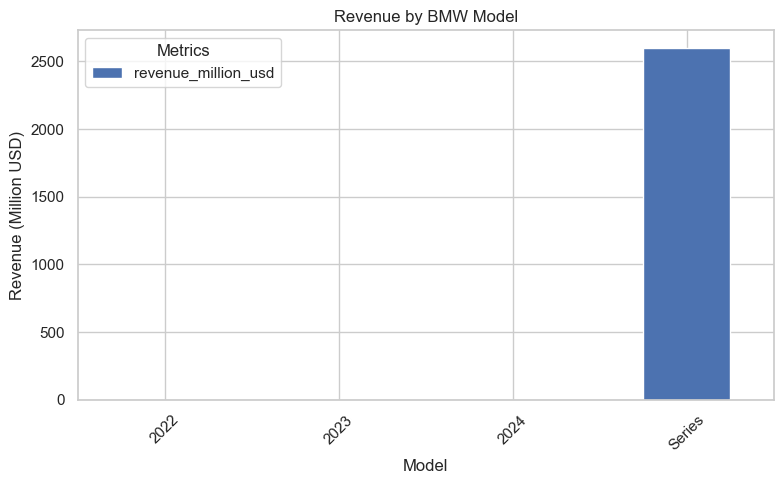

In [28]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset (fix separator issue)
data = pd.read_csv('bmw_sales.csv', sep=r'\s+')

# Clean column names
data.columns = data.columns.str.strip().str.lower()

# Verify columns
print("Columns in dataset:", data.columns.tolist())

# Group by model and calculate total revenue
model_revenue = data.groupby('model')[['revenue_million_usd']].sum()

# Print results
print("\nModel Revenue:")
print(model_revenue)

# Plot bar chart
model_revenue.plot(kind='bar', figsize=(8,5))

plt.title("Revenue by BMW Model")
plt.xlabel("Model")
plt.ylabel("Revenue (Million USD)")
plt.xticks(rotation=45)
plt.legend(title="Metrics")

plt.tight_layout()
plt.show()



In [31]:
data.columns = data.columns.str.strip().str.title()



Columns are: ['Model', 'Year', 'Units_Sold', 'Revenue_Million_Usd']
Year      2021   7000   9000    12000   19000   28000
Model                                                
2022        NaN    NaN    NaN     NaN  1520.0  1680.0
2023        NaN    NaN  540.0  1080.0     NaN     NaN
2024        NaN  630.0    NaN     NaN     NaN     NaN
Series  53000.0    NaN    NaN     NaN     NaN     NaN


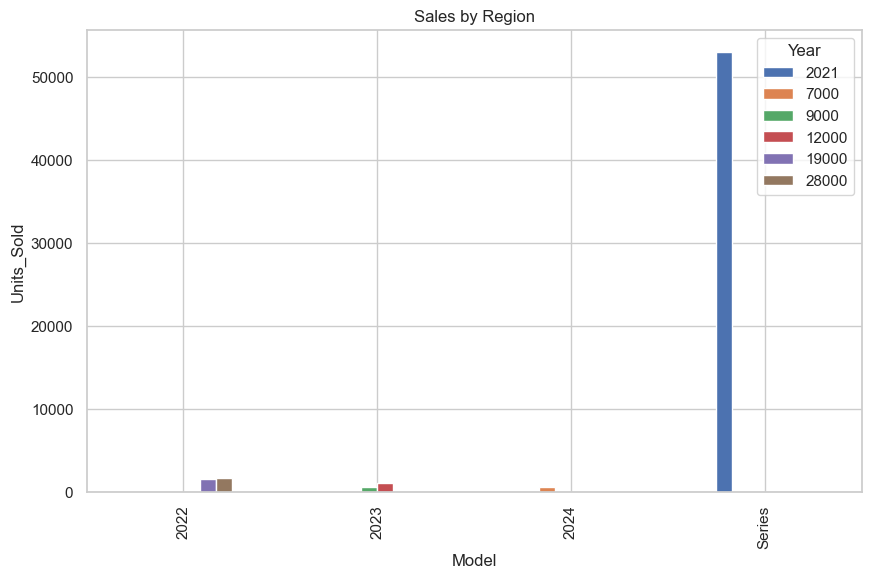

In [34]:
import matplotlib.pyplot as plt

# Clean column names
data.columns = data.columns.str.strip()

# Print columns so you can see them
print("Columns are:", data.columns.tolist())

# Replace these names with EXACT matches from your dataset
region_col = data.columns[0]   # first column
brand_col = data.columns[1]    # second column
sales_col = data.columns[2]    # third column

region_sales = data.groupby([region_col, brand_col])[sales_col].sum().unstack()

print(region_sales)

region_sales.plot(kind='bar')

plt.title("Sales by Region")
plt.xlabel(region_col)
plt.ylabel(sales_col)

plt.show()


In [36]:
data.columns = data.columns.str.strip()
print(data.columns)


Index(['Model', 'Year', 'Units_Sold', 'Revenue_Million_Usd'], dtype='object')


In [37]:
for col in data.columns:
    print(f"'{col}'")


'Model'
'Year'
'Units_Sold'
'Revenue_Million_Usd'


In [41]:
print(data.columns)



Index(['Model', 'Year', 'Units_Sold', 'Revenue_Million_Usd'], dtype='object')


In [42]:
data.columns = data.columns.str.strip()



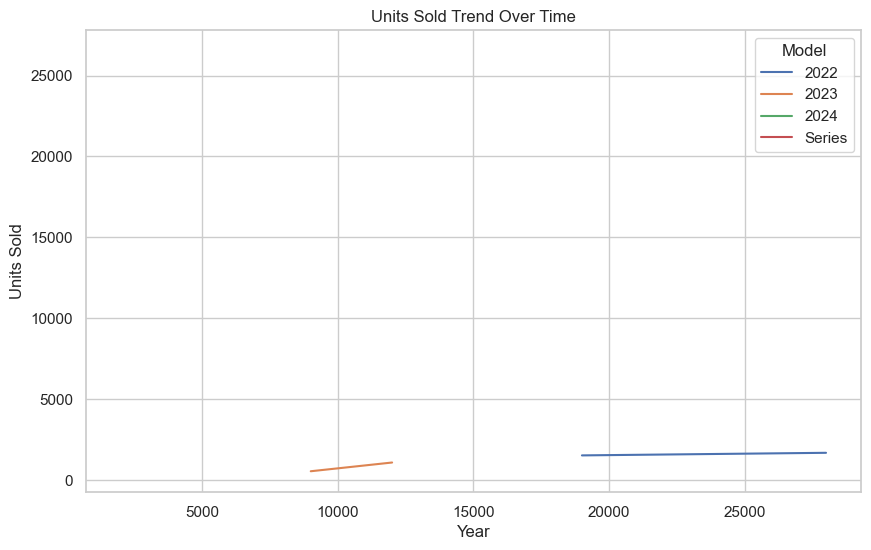

In [45]:
import matplotlib.pyplot as plt

data.columns = data.columns.str.strip()

trend = data.groupby(['Year', 'Model'])['Units_Sold'].mean().unstack()

trend.plot(figsize=(10,6))
plt.title("Units Sold Trend Over Time")
plt.xlabel("Year")
plt.ylabel("Units Sold")
plt.legend(title="Model")
plt.grid(True)

plt.show()


In [47]:
import pandas as pd

# Example BMW data
bmw = pd.DataFrame({
    "Model": ["X5", "3 Series", "5 Series"],
    "Price": [65000, 45000, 55000],
    "Horsepower": [335, 255, 335]
})

# Example Toyota data
toyota = pd.DataFrame({
    "Model": ["RAV4", "Camry", "Corolla"],
    "Price": [30000, 28000, 23000],
    "Horsepower": [203, 203, 169]
})

# Create comparison DataFrame
comparison = pd.concat(
    [bmw.add_prefix("BMW_"), toyota.add_prefix("Toyota_")],
    axis=1
)

# Export to CSV
comparison.to_csv("bmw_vs_toyota_comparison.csv", index=False)

print("CSV file saved successfully.")


CSV file saved successfully.
